## Working with Transformers in the HuggingFace Ecosystem

In this laboratory exercise we will learn how to work with the HuggingFace ecosystem to adapt models to new tasks. As you will see, much of what is required is *investigation* into the inner-workings of the HuggingFace abstractions. With a little work, a little trial-and-error, it is fairly easy to get a working adaptation pipeline up and running.

### Used tools
In this laboratory I used Copilot inline as support while writing the code.

In [1]:
import random
import numpy as np
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


Device: cuda


**It is important to run this notebook from the first cell because there are dependences between distant cells of the notebook**
To run just a specific part take attention of the dependences above.

### Exercise 1: Sentiment Analysis (warm up)

In this first exercise we will start from a pre-trained BERT transformer and build up a model able to perform text sentiment analysis. Transformers are complex beasts, so we will build up our pipeline in several explorative and incremental steps.

#### Exercise 1.1: Dataset Splits and Pre-trained model
There are a many sentiment analysis datasets, but we will use one of the smallest ones available: the [Cornell Rotten Tomatoes movie review dataset](cornell-movie-review-data/rotten_tomatoes), which consists of 5,331 positive and 5,331 negative processed sentences from the Rotten Tomatoes movie reviews.

**Your first task**: Load the dataset and figure out what splits are available and how to get them. Spend some time exploring the dataset to see how it is organized. Note that we will be using the [HuggingFace Datasets](https://huggingface.co/docs/datasets/en/index) library for downloading, accessing, splitting, and batching data for training and evaluation.

In [2]:
from datasets import load_dataset, get_dataset_split_names
from collections import Counter

splits = get_dataset_split_names("cornell-movie-review-data/rotten_tomatoes")
print("Available splits:", splits)

dataset = load_dataset("cornell-movie-review-data/rotten_tomatoes")
print(dataset)
print(dataset["train"][0])
print(dataset["validation"][0])
print(dataset["test"][0])

train_labels = dataset["train"]["label"]
counts = Counter(train_labels)

print("Negative number:", counts[0])
print("Positive number:", counts[1])
# Evidentemente sono stati tolti svariati dati

for split in dataset.keys():
    labels = dataset[split]["label"]
    counts = Counter(labels)
    print(f"{split}: total={len(labels)}, negatives={counts.get(0,0)}, positives={counts.get(1,0)}")
    # Ok mi torna ci sono effettivamente 5331 positivi e 5331 negativi

Available splits: ['train', 'validation', 'test']
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})
{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1}
{'text': 'compassionately explores the seemingly irreconcilable situation between conservative christian parents and their estranged gay and lesbian children .', 'label': 1}
{'text': 'lovingly photographed in the manner of a golden book sprung to life , stuart little 2 manages sweetness largely without stickiness .', 'label': 1}
Negative number: 4265
Positive number: 4265
train: total=8530, negatives=4265, positives=4265
validation: total=1066, negatives=53

**I left the comments in Italian because at first I was so confused that they deserve to stay there.**

#### Exercise 1.2: A Pre-trained BERT and Tokenizer

The model we will use is a *very* small BERT transformer called [Distilbert](https://huggingface.co/distilbert/distilbert-base-uncased) this model was trained (using self-supervised learning) on the same corpus as BERT but using the full BERT base model as a *teacher*.

**Your next task**: Load the Distilbert model and corresponding tokenizer. Use the tokenizer on a few samples from the dataset and pass the tokens through the model to see what outputs are provided. I suggest you use the [`AutoModel`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html) class (and the `from_pretrained()` method) to load the model and `AutoTokenizer` to load the tokenizer).

In [3]:
from transformers import AutoTokenizer, AutoModel

samples = [dataset["train"][i]["text"] for i in range(3)]
print("Examples:\n", "\n---\n".join(samples))

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
# DistilBERT encoder with no task-specific head
model = AutoModel.from_pretrained("distilbert-base-uncased").to(device)

model.eval()

# Tokenizer
encoded = tokenizer(
    samples,
    padding=True, # pad all sequences in the batch to the same length
    truncation=True, # cut sequences longer than the model's max length (512)
    return_tensors="pt"
).to(device)

print("\nTokenized keys:", list(encoded.keys()))
print("input_ids shape:", encoded["input_ids"].shape)
print("attention_mask shape:", encoded["attention_mask"].shape)

with torch.no_grad(): # no gradients needed, output of the DistilBERT model
    outputs = model(**encoded)

print("\nOutput keys:", outputs.keys())

last_hidden = outputs.last_hidden_state
print("last_hidden_state shape:", last_hidden.shape)

# Every sequence has a [CLS] token's contextual representation at the 0th position,
# a sort of "summary" embedding of the entire sentence for classification tasks
cls_repr = last_hidden[:, 0, :]
print("CLS token 0 shape:", cls_repr.shape)


Examples:
 the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .
---
the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson's expanded vision of j . r . r . tolkien's middle-earth .
---
effective but too-tepid biopic


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Tokenized keys: ['input_ids', 'token_type_ids', 'attention_mask']
input_ids shape: torch.Size([3, 52])
attention_mask shape: torch.Size([3, 52])

Output keys: odict_keys(['last_hidden_state'])
last_hidden_state shape: torch.Size([3, 52, 768])
CLS token 0 shape: torch.Size([3, 768])


`last_hidden_state` is `[batch=3, seq_len=52, hidden=768]` so one 768-dim vector per token, per sentence.

#### Exercise 1.3: A Stable Baseline

In this exercise I want you to:
1. Use Distilbert as a *feature extractor* to extract representations of the text strings from the dataset splits;
2. Train a classifier (your choice, by an SVM from Scikit-learn is an easy choice).
3. Evaluate performance on the validation and test splits.

These results are our *stable baseline* -- the **starting** point on which we will (hopefully) improve in the next exercise.

**Hint**: There are a number of ways to implement the feature extractor, but probably the best is to use a [feature extraction `pipeline`](https://huggingface.co/tasks/feature-extraction). You will need to interpret the output of the pipeline and extract only the `[CLS]` token from the *last* transformer layer. *How can you figure out which output that is?*

In [4]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

def extract_cls_embeddings(texts, batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**encoded)
        # Same trick as before
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

    return np.concatenate(all_embeddings, axis=0)

# Prepare data
X_train = extract_cls_embeddings(dataset["train"]["text"])
y_train = np.array(dataset["train"]["label"])

X_val = extract_cls_embeddings(dataset["validation"]["text"])
y_val = np.array(dataset["validation"]["label"])

X_test = extract_cls_embeddings(dataset["test"]["text"])
y_test = np.array(dataset["test"]["label"])

print("Train features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Test features:", X_test.shape)

# Train classifier, LinearSVC on frozen features, it shows how good DistilBERT's pretrained representations already are
clf = LinearSVC()
clf.fit(X_train, y_train)

# Evaluate
val_pred = clf.predict(X_val)
test_pred = clf.predict(X_test)

baseline_val_acc = accuracy_score(y_val, val_pred)
baseline_test_acc = accuracy_score(y_test, test_pred)

print(f"Validation accuracy: {baseline_val_acc:.4f}")
print(f"Test accuracy: {baseline_test_acc:.4f}")

print("\nValidation report:")
print(classification_report(y_val, val_pred, target_names=["negative", "positive"]))

print("\nTest report:")
print(classification_report(y_test, test_pred, target_names=["negative", "positive"]))


Train features: (8530, 768)
Validation features: (1066, 768)
Test features: (1066, 768)
Validation accuracy: 0.8218
Test accuracy: 0.7983

Validation report:
              precision    recall  f1-score   support

    negative       0.81      0.84      0.83       533
    positive       0.84      0.80      0.82       533

    accuracy                           0.82      1066
   macro avg       0.82      0.82      0.82      1066
weighted avg       0.82      0.82      0.82      1066


Test report:
              precision    recall  f1-score   support

    negative       0.79      0.81      0.80       533
    positive       0.81      0.78      0.80       533

    accuracy                           0.80      1066
   macro avg       0.80      0.80      0.80      1066
weighted avg       0.80      0.80      0.80      1066



#### Observations (Exercise 1.3)
Stable baseline with precision, recall, f1, support and accuracy value on validation and test set, on LinearSVC from Scikit-learn SVM.

The baseline reaches 82.2% validation / 79.8% test accuracy, with balanced precision/recall on both classes. This confirms the feature extraction pipeline works correctly (~80% test accuracy). The fine-tuned model in Exercise 2.3 should be able to beat, since fine-tuning lets the representations adapt specifically to the sentiment task, instead of relying on generic pretrained embeddings.

-----
### Exercise 2: Fine-tuning Distilbert

In this exercise we will fine-tune the Distilbert model to (hopefully) improve sentiment analysis performance.

#### Exercise 2.1: Token Preprocessing

The first thing we need to do is *tokenize* our dataset splits. Our current datasets return a dictionary with *strings*, but we want *input token ids* (i.e. the output of the tokenizer). This is easy enough to do my hand, but the HugginFace `Dataset` class provides convenient, efficient, and *lazy* methods. See the documentation for [`Dataset.map`](https://huggingface.co/docs/datasets/v3.5.0/en/package_reference/main_classes#datasets.Dataset.map).

**Tip**: Verify that your new datasets are returning for every element: `text`, `label`, `intput_ids`, and `attention_mask`.

In [5]:
# Your code here.
from transformers import AutoTokenizer

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    # No padding here, the padding is delegated
    return tokenizer(
        examples["text"],
        truncation=True
    )

# Tokenize all splits one batch at a time
tokenized_dataset = dataset.map(tokenize_function, batched=True)

print(tokenized_dataset)
print(tokenized_dataset["train"][0])
print(tokenized_dataset["validation"][0])
print(tokenized_dataset["test"][0])

tokenized_dataset = tokenized_dataset.remove_columns(["text"])

print(tokenized_dataset)
print(tokenized_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1066
    })
})
{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1, 'input_ids': [101, 1996, 2600, 2003, 16036, 2000, 2022, 1996, 7398, 2301, 1005, 1055, 2047, 1000, 16608, 1000, 1998, 2008, 2002, 1005, 1055, 2183, 2000, 2191, 1037, 17624, 2130, 3618, 2084, 7779, 29058, 8625, 13327, 1010, 3744, 1011, 18856, 19513, 3158, 5477, 4168, 2030, 7112, 16562, 2140, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

#### Exercise 2.2: Setting up the Model to be Fine-tuned

In this exercise we need to prepare the base Distilbert model for fine-tuning for a *sequence classification task*. This means, at the very least, appending a new, randomly-initialized classification head connected to the `[CLS]` token of the last transformer layer. Luckily, HuggingFace already provides an `AutoModel` for just this type of instantiation: [`AutoModelForSequenceClassification`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html#automodelforsequenceclassification). You will want you instantiate one of these for fine-tuning.

In [6]:
# Your code here.
from transformers import AutoModelForSequenceClassification

id2label = {0: "negative", 1: "positive"}
label2id = {"negative": 0, "positive": 1}

# Sequence classification model for binary sentiment analysis
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

print(model)

# Sanity check
sample_batch = tokenized_dataset["train"][:2]
print(sample_batch.keys())


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

#### Exercise 2.3: Fine-tuning Distilbert

Finally. In this exercise you should use a HuggingFace [`Trainer`](https://huggingface.co/docs/transformers/main/en/trainer) to fine-tune your model on the Rotten Tomatoes training split. Setting up the trainer will involve (at least):


1. Instantiating a [`DataCollatorWithPadding`](https://huggingface.co/docs/transformers/en/main_classes/data_collator) object which is what *actually* does your batch construction (by padding all sequences to the same length).
2. Writing an *evaluation function* that will measure the classification accuracy. This function takes a single argument which is a tuple containing `(logits, labels)` which you should use to compute classification accuracy (and maybe other metrics like F1 score, precision, recall) and return a `dict` with these metrics.  
3. Instantiating a [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.51.1/en/main_classes/trainer#transformers.TrainingArguments) object using some reasonable defaults.
4. Instantiating a `Trainer` object using your train and validation splits, you data collator, and function to compute performance metrics.
5. Calling `trainer.train()`, waiting, waiting some more, and then calling `trainer.evaluate()` to see how it did.

**Tip**: When prototyping this laboratory I discovered the HuggingFace [Evaluate library](https://huggingface.co/docs/evaluate/en/index) which provides evaluation metrics. However I found it to have insufferable layers of abstraction and getting actual metrics computed. I suggest just using the Scikit-learn metrics...

In [7]:
# Your code here.
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Data collator: pads sequences to the same length within each batch
# to the longest sequence in that batch (not globally)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataset = tokenized_dataset["train"]
eval_dataset = tokenized_dataset["validation"]
test_dataset = tokenized_dataset["test"]

# 2. Evaluation function
def evaluation_funct(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1
    }

# 3. Training arguments
training_args = TrainingArguments(
    output_dir="distilbert-rotten-tomatoes-finetune",
    eval_strategy="epoch", # evaluate at the end of every epoch
    save_strategy="epoch",
    learning_rate=2e-5, # standard fine-tuning LR for BERT-family models
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100,
    # To avoid saving an overfitted model
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(), # use mixed precision only if a GPU is
)

# 4. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=evaluation_funct,
)

# 5. Train
train_result = trainer.train()
trainer.save_model(training_args.output_dir)

eval_metrics = trainer.evaluate(eval_dataset=eval_dataset)
print("Validation metrics:", eval_metrics)

test_metrics = trainer.evaluate(eval_dataset=test_dataset)
print("Test metrics:", test_metrics)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.348605,0.384141,0.840525,0.793215,0.921201,0.852431
2,0.253652,0.385810,0.845216,0.842007,0.849906,0.845938
3,0.146153,0.495751,0.846154,0.841035,0.853659,0.847300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.146153,0.384141,3,0.840525,0.793215,0.921201,0.852431


Validation metrics: {'eval_loss': 0.38414061069488525, 'eval_accuracy': 0.8405253283302064, 'eval_precision': 0.7932148626817448, 'eval_recall': 0.9212007504690432, 'eval_f1': 0.8524305555555556}


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.146153,0.418357,3,0.826454,0.779743,0.909944,0.839827


Test metrics: {'eval_loss': 0.4183565080165863, 'eval_accuracy': 0.8264540337711069, 'eval_precision': 0.7797427652733119, 'eval_recall': 0.9099437148217636, 'eval_f1': 0.8398268398268398}


In [8]:
# Comparison with the Exercise 1.3 baseline
print("Baseline (Distilbert frozen + LinearSVC)")
print(f"  Validation accuracy: {baseline_val_acc:.4f}")
print(f"  Test accuracy:       {baseline_test_acc:.4f}")

print("\nFine-tuned Distilbert")
print(f"  Validation accuracy: {eval_metrics['eval_accuracy']:.4f}")
print(f"  Test accuracy:       {test_metrics['eval_accuracy']:.4f}")

print(f"\nImprovements on test set: {(test_metrics['eval_accuracy'] - baseline_test_acc) * 100:+.2f}")


Baseline (Distilbert frozen + LinearSVC)
  Validation accuracy: 0.8218
  Test accuracy:       0.7983

Fine-tuned Distilbert
  Validation accuracy: 0.8405
  Test accuracy:       0.8265

Improvements on test set: +2.81


#### Observations (Exercise 2.3):
Fine-tuning improves test accuracy from 79.8% (baseline) to 82.6% (+2.8), confirming that adapting the representations to the task helps. The best checkpoint (by validation F1) is the one from epoch 1, from epoch 2 validation loss worsens while training loss keeps decreasing, a sign of overfitting. The fine-tuned model also shows a much higher recall than precision on the positive class (0.91 vs 0.78) compared to the baseline, which was more balanced: this suggests a tendency to predict "positive" more often.

-----
### Exercise 3: Choose at Least One


#### Exercise 3.1: Efficient Fine-tuning for Sentiment Analysis (easy)

In Exercise 2 we fine-tuned the *entire* Distilbert model on Rotten Tomatoes. This is expensive, even for a small model. Find an *efficient* way to fine-tune Distilbert on the Rotten Tomatoes dataset (or some other dataset).

**Hint**: You could check out the [HuggingFace PEFT library](https://huggingface.co/docs/peft/en/index) for some state-of-the-art approaches that should "just work". How else might you go about making fine-tuning more efficient without having to change your training pipeline from above?

In [9]:
# Your code here.

#### Exercise 3.2: Fine-tuning a CLIP Model (harder)

Use a (small) CLIP model like [`openai/clip-vit-base-patch16`](https://huggingface.co/openai/clip-vit-base-patch16) and evaluate its zero-shot performance on a small image classification dataset like ImageNette or TinyImageNet. Fine-tune (using a parameter-efficient method!) the CLIP model to see how much improvement you can squeeze out of it.

**Note**: There are several ways to adapt the CLIP model; you could fine-tune the image encoder, the text encoder, or both. Or, you could experiment with prompt learning.

**Tip**: CLIP probably already works very well on ImageNet and ImageNet-like images. For extra fun, look for an image classification dataset with different image types (e.g. *sketches*).

In [10]:
# Your code here.

#### Exercise 3.3: Choose your Own Adventure

There are a *ton* of interesting and fun models on the HuggingFace hub. Pick one that does something interesting and adapt it in some way to a new task. Or, combine two or more models into something more interesting or fun. The sky's the limit.

**Note**: Reach out to me by email or on the Discord if you are unsure about anything.

In [11]:
import os
# Disable HuggingFace's Xet transfer backend and go back to the classic HTTP
# downloader. The downaload stope at a certain point so I had to disable Xet.
os.environ["HF_HUB_DISABLE_XET"] = "1"

### Idea: two pre-trained pipelines:
- BLIP a model for image captioning that allow to describe the meme in a single phrase
- Fine-tuned Distilbert from exercise 2 to classify the caption as postive/negative

[<PIL.PngImagePlugin.PngImageFile image mode=P size=500x450 at 0x742C181A5D30>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x254 at 0x742C181A6120>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=627x946 at 0x742C1819E210>, <PIL.PngImagePlugin.PngImageFile image mode=P size=500x585 at 0x742C1819EFD0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1280x720 at 0x742C1819F110>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=480x639 at 0x742C1816AD70>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=620x350 at 0x742C1816B490>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=611x611 at 0x742C1816B820>]


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Modello caricato


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

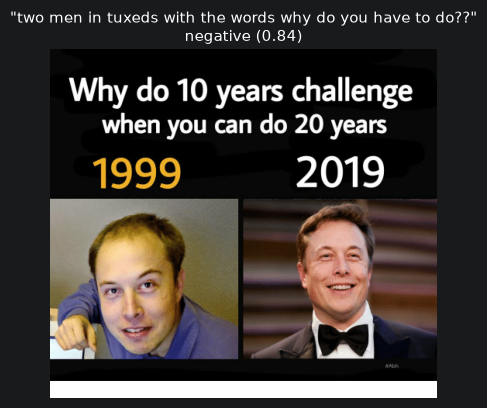

Caption: two men in tuxeds with the words why do you have to do??
Sentiment: {'label': 'negative', 'score': 0.8369184732437134}
---


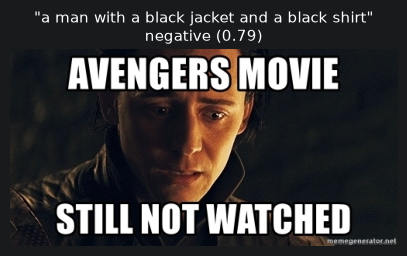

Caption: a man with a black jacket and a black shirt
Sentiment: {'label': 'negative', 'score': 0.7890213131904602}
---


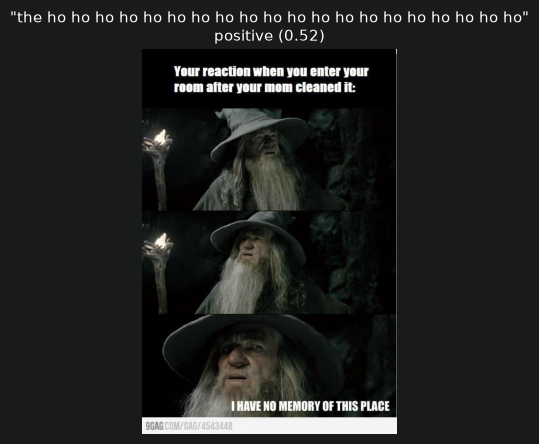

Caption: the ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho
Sentiment: {'label': 'positive', 'score': 0.5233482718467712}
---


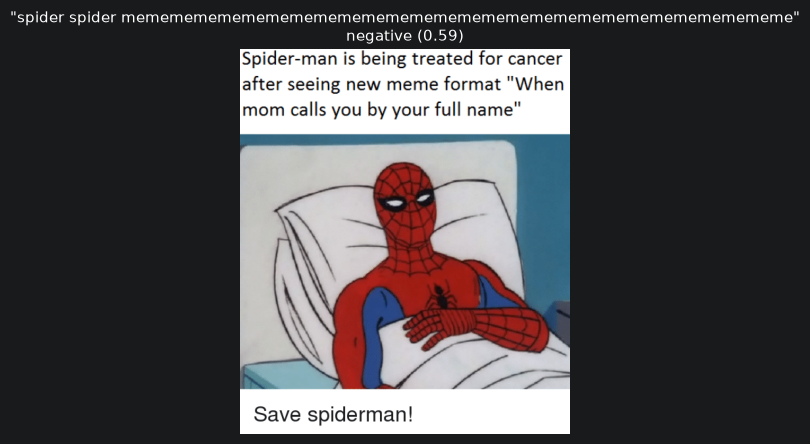

Caption: spider spider memememememememememememememememememememememememememememe
Sentiment: {'label': 'negative', 'score': 0.58902508020401}
---


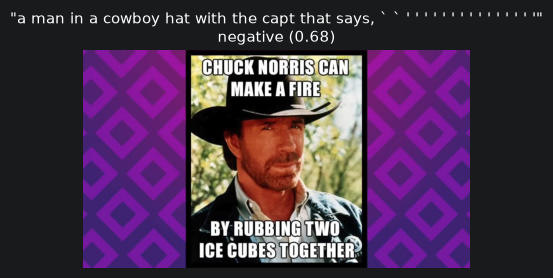

Caption: a man in a cowboy hat with the capt that says, ` ` ' ' ' ' ' ' ' ' ' ' ' ' ' ' '
Sentiment: {'label': 'negative', 'score': 0.6828657388687134}
---


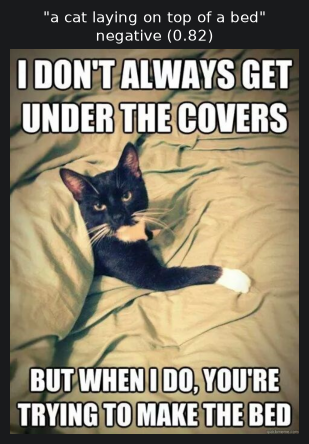

Caption: a cat laying on top of a bed
Sentiment: {'label': 'negative', 'score': 0.8213834166526794}
---


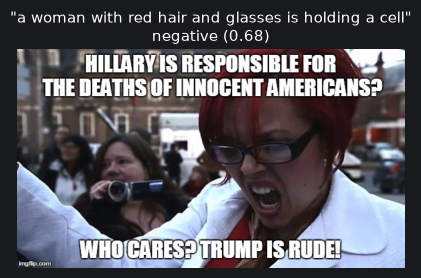

Caption: a woman with red hair and glasses is holding a cell
Sentiment: {'label': 'negative', 'score': 0.6837754249572754}
---


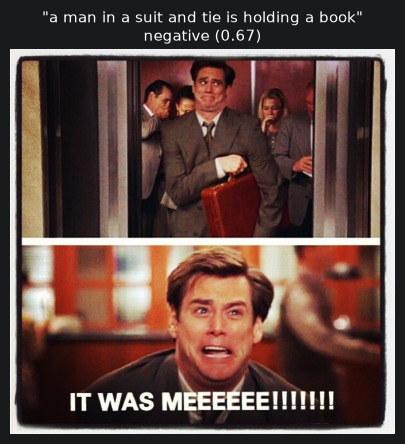

Caption: a man in a suit and tie is holding a book
Sentiment: {'label': 'negative', 'score': 0.6709691286087036}
---


In [13]:
from transformers import BlipProcessor, BlipForConditionalGeneration, pipeline
from PIL import Image
import matplotlib.pyplot as plt
from datasets import load_dataset

# Import dataset meme
meme_ds = load_dataset("Ahren09/MMSoc_Memotion", split="train")
meme_ds_shuffled = meme_ds.shuffle(seed=random.randint(0, 10_000))

n_samples = 8
sample_images = [meme_ds_shuffled[i]["image"] for i in range(n_samples)]
print(sample_images)

# 1. Loading the image captioning model
caption_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
caption_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

def generate_caption(image: Image.Image) -> str:
    inputs = caption_processor(image, return_tensors="pt").to(device)
    out = caption_model.generate(**inputs, max_new_tokens=30)
    return caption_processor.decode(out[0], skip_special_tokens=True)

# 2. Loading sentiment classification from exercise 2.3, the FINE-TUNED checkpoint saved
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=training_args.output_dir,
    device= device,
)

# 3. Function: meme -> caption -> sentiment
def analyze_meme(image: Image.Image):
    caption = generate_caption(image)
    sentiment = sentiment_pipe(caption)[0]
    return caption, sentiment

def show_meme_analysis(image: Image.Image):
    caption, sentiment = analyze_meme(image)
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f'"{caption}"\n{sentiment["label"]} ({sentiment["score"]:.2f})', fontsize=11)
    plt.show()
    return caption, sentiment

for img in sample_images:
    caption, sentiment = show_meme_analysis(img)
    print(f"Caption: {caption}")
    print(f"Sentiment: {sentiment}")
    print("---")


#### Observations (Exercise 3.3):
Some caption and sentiment prediction are related like "two men in tuxeds with the words why do you have to do??" with a negative response.

"the ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho ho" could recall Santa Claus and it's classified as positive.

Others like "spider spider memememememememememememememememememememememememememememe" actually doesn't make sense a lot, probably has been classified as negative because the model, of course, doesn't catch irony or sarcasm, in particulare if we are talking about meme.

Funny thing: "a man in a suit and tie is holding a book" that could be a teacher, the sentiment prediction is negative, I think the model fed up of learning.

Not the best things to do with two models in a pipeline but it's funny.

## Final Conclusions

This laboratory it gives a throwback time to first years of university when I learned that we don't have to implement everything if somebody has already done what are you going to implement. On the Rotten Tomatoes sentiment task, frozen DistilBERT [CLS] embeddings fed into a linear SVM already reach a strong, balanced baseline (82.2% validation / 79.8% test accuracy), s DistilBERT's pre-trained representation is already task-relevant with zero adaptation. But is it possibile to improve it? End-to-end fine-tuning improves on this baseline by +2.8 points of test accuracy, this confirm that is it possible to adapt the model to a specifica task and yields a real, if modest, gain, even though it's important to be careful because it's easy to overfit (validation performance peaks after epoch 1 out of 3) and a precision/recall imbalance on the positive class that the frozen baseline did not show. I honestly didn't expect to overfit so fast.

The exercise 3: here I enjoyed the process and even more the results, chaining a BLIP image captioner into the fine-tuned sentiment classifier to analyze memes. The qualitative failures observed (irony and meme-specific humor consistently misread as negative, degenerate captions occasionally producing nonsensical sentiment calls) trace lead me to this explanation: a text-only sentiment model fine-tuned on literal movie-review has no mechanism to represent tone, sarcasm, or visual context, in a context like memes, that often are difficult even for us human to understand, and also different people can perceive sarcasm way differently from each other, so it's interesting look how a model classifies memes.

Overall, this lab shows that fine-tuning is worth its cost even for a "small" model and a "small" dataset, that overfitting risk is real and scales faster than intuition suggests, and that we can have fun with AI models, and it's very interesting observ how models interact with sophisticated complex human superior "processing" like sarcasm and tone. (also very fun to discover that it's possibile to pipeline models and have fun with the possible disaster or perfect combination of them)